# Factores y series temporales en Python 
### Clase 4: Práctica (2 h)
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---

Del mundo $\mathbb{Q}$ al mundo $\mathbb{P}$

| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | CAPM y Fama-French | α y β de acciones reales; factores construidos con ETFs → ¿mejora el R²? |
| **2** | ARIMA vs GARCH | El fracaso instructivo (retornos) y el éxito (volatilidad) → VaR condicional con backtest |
| **3** | Lasso vs Ridge | Panel de factores reales + ruido inyectado: la selección automática, en vivo |
| **4** | El factor que muere *(extra)* | HML (Ken French, 1926-hoy), McLean-Pontiff (2016) |




> **Ejercicio 1 (CAPM y Fama-French):**
> 1. ¿Esperás que el R² suba MUCHO al pasar de CAPM (solo MKT) a Fama-French (MKT+SMB+HML)? ¿Qué le pasaría a los α si los factores nuevos explicaran lo que el mercado solo no explicaba?
> 2. De las 6 acciones (AAPL, NVDA, JPM, XOM, KO, F), ¿cuál esperás que tenga el β más alto? ¿Y el más bajo, casi nulo?
>
> **Ejercicio 2 (ARIMA vs GARCH):**

> 3. ¿El mejor ARIMA elegido por AIC va a pronosticar algo DISTINTO del promedio histórico de los retornos? ¿Por qué sí o por qué no, antes de correrlo?
> 4. GARCH(1,1) va a dar α+β ¿cerca de 0, cerca de 0.5, o cerca de 1? ¿Qué significaría cada caso para cuánto "dura" un shock de volatilidad?
>
> **Ejercicio 3, (Lasso vs Ridge):**

> 5. ¿Esperás que Lasso ponga en CERO EXACTO a los 5 factores fantasma, o que solo los achique como Ridge? ¿Qué diferencia geométrica entre L1 y L2 (§8 de la teórica) explica tu respuesta?
> 6. ¿Creés que el R² out-of-sample de Ridge/Lasso le va a GANAR a OLS, o que solo va a igualarlo?
>
> **Ejercicio 4, (El factor que se muere al publicarse):**

> 7. Si McLean-Pontiff (2016) tienen razón, ¿el Sharpe de HML debería ser MAYOR o MENOR después de 1993? Den un número aproximado de cuánto esperan que caiga (en %).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED = '#2E7D32', '#C62828'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})
print('Listo.')

/Users/guido_ss/Library/Mobile Documents/com~apple~CloudDocs/Documents/Proyecto_CLASES_FINANZAS/Curso_v2/clase4/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Listo.


---
# Ejercicio 1: CAPM y Fama-French con ETFs

## La idea

Primero la regresión más famosa de las finanzas, para varias acciones reales:

$$r_i - r_f = \alpha_i + \beta_i\,(r_m - r_f) + \varepsilon_i$$

con su **error estándar** (β sin barras de error es mala práctica) y su R².

Después, los factores de Fama-French, pero construidos con **ETFs líquidos** en vez de la
data library académica (más robusto en vivo, y muestra que un factor es una *estrategia comprable*):

- $MKT$ = SPY − rf (el mercado de siempre)
- $SMB \approx$ IWM − SPY (chicas menos grandes)
- $HML \approx$ IVE − IVW (value menos growth, S&P 500)

A la regresión con los tres factores juntos (MKT + SMB + HML) la vamos a llamar **FF3**
(el modelo de tres factores de Fama-French, para abreviar). La comparación de todo este
ejercicio es **CAPM** (una sola variable, el mercado) contra **FF3** (las tres juntas):
¿cuánto sube el R² al pasar de una a tres, y qué le pasa al α?

La pregunta: al agregar factores, ¿cuánto sube el R² y cuánto se achican los α?

> *(Predicción: preguntas 1-2, ya las escribiste arriba de todo, antes de empezar.)*

In [2]:
# ── Datos: 6 acciones contrastantes + los 4 ETFs de factores ─────────────────
TICKERS = ['AAPL', 'NVDA', 'JPM', 'XOM', 'KO', 'F']
ETFS    = ['SPY', 'IWM', 'IVE', 'IVW']

try:
    px = yf.download(TICKERS + ETFS, period='3y', progress=False)['Close'].dropna()
    fuente = 'datos en vivo (Yahoo Finance)'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(1)
    idx = pd.date_range('2023-07-01', periods=750, freq='B')
    mkt = rng.normal(0.0004, 0.011, 750)
    data = {t: 0.0002 + (0.8 + 0.1*i)*mkt + rng.normal(0, 0.012, 750) for i, t in enumerate(TICKERS + ETFS)}
    px = (1 + pd.DataFrame(data, index=idx)).cumprod() * 100

rets = np.log(px / px.shift(1)).dropna()
rf_d = 0.04 / 252                              # tasa libre de riesgo diaria (aprox ^IRX)
print(f'[{fuente}] {len(rets)} días, {rets.index[0].date()} → {rets.index[-1].date()}')

[datos en vivo (Yahoo Finance)] 752 días, 2023-09-13 → 2026-09-11


In [3]:
# ── CAPM: α, β, SE(β) y R² por acción ─────────────────────────────────────────
mkt = rets['SPY'] - rf_d

def regresion(y, X):
    """OLS con intercepto: devuelve coefs, SEs y R²."""
    X = np.column_stack([np.ones(len(X)), X])
    coef, res, *_ = np.linalg.lstsq(X, y, rcond=None)
    e = y - X @ coef
    s2 = e @ e / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    r2 = 1 - (e @ e) / ((y - y.mean()) @ (y - y.mean()))
    return coef, se, r2

print(f'{"":<6}{"beta":>7}{"SE(β)":>8}{"alpha anual":>13}{"R²":>7}')
capm = {}
for tk in TICKERS:
    y = rets[tk] - rf_d
    coef, se, r2 = regresion(y.values, mkt.values)
    capm[tk] = {'alpha': coef[0]*252, 'beta': coef[1], 'se': se[1], 'r2': r2}
    print(f'{tk:<6}{coef[1]:>7.2f}{se[1]:>8.2f}{coef[0]*252:>+12.1%}{r2:>7.0%}')

print('\nLeer con las barras de error: β = 1.3 ± 0.1, el número solo es media verdad.')

         beta   SE(β)  alpha anual     R²
AAPL     1.05    0.05       +1.6%    36%
NVDA     2.04    0.08      +17.9%    44%
JPM      0.87    0.04      +14.7%    34%
XOM      0.21    0.06       +7.7%     2%
KO       0.03    0.04      +12.5%     0%
F        1.01    0.08       -9.3%    18%

Leer con las barras de error: β = 1.3 ± 0.1, el número solo es media verdad.


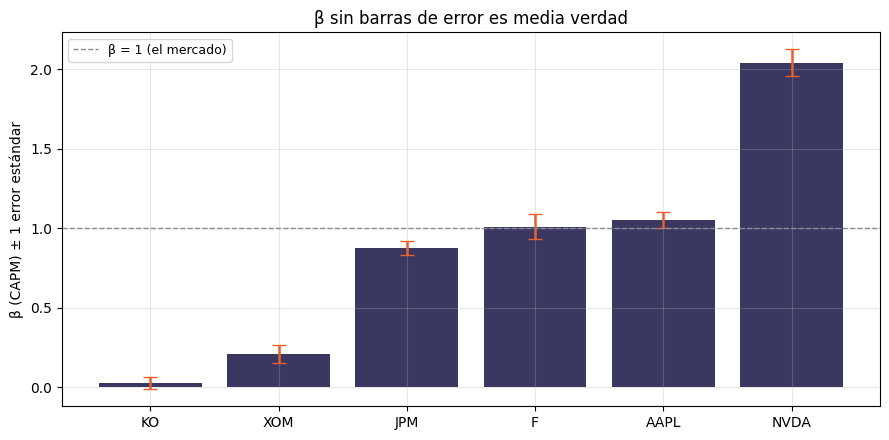

In [4]:
# ── La figura: β con barras de error, la que el texto de arriba pide ────────
orden = sorted(capm, key=lambda t: capm[t]['beta'])
betas = [capm[t]['beta'] for t in orden]
ses   = [capm[t]['se'] for t in orden]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(orden, betas, yerr=ses, capsize=5, color=NAVY, alpha=0.88,
       error_kw={'ecolor': ORANGE, 'elinewidth': 1.8})
ax.axhline(1.0, color='#8A8A9A', ls='--', lw=1, label='β = 1 (el mercado)')
ax.set_ylabel('β (CAPM) ± 1 error estándar')
ax.set_title('β sin barras de error es media verdad')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


In [5]:
# ── Fama-French con ETFs: ¿mejora sobre el CAPM? ──────────────────────────────
factores = pd.DataFrame({
    'MKT': rets['SPY'] - rf_d,
    'SMB': rets['IWM'] - rets['SPY'],       # chicas − grandes
    'HML': rets['IVE'] - rets['IVW'],       # value − growth
})

print('Correlaciones entre factores (deberían ser bajas para que cada uno aporte):')
print(factores.corr().round(2).to_string())
print()
print(f'{"":<6}{"β_MKT":>7}{"s (SMB)":>9}{"h (HML)":>9}{"α FF3":>9}{"α CAPM":>9}{"R² FF3":>8}{"R² CAPM":>9}')
for tk in TICKERS:
    y = rets[tk] - rf_d
    coef, se, r2 = regresion(y.values, factores.values)
    print(f'{tk:<6}{coef[1]:>7.2f}{coef[2]:>9.2f}{coef[3]:>9.2f}{coef[0]*252:>+9.1%}{capm[tk]["alpha"]:>+9.1%}{r2:>8.0%}{capm[tk]["r2"]:>9.0%}')

print()
print('Lecturas: s > 0 = se comporta como chica; h > 0 = como value, h < 0 = como growth.')

Correlaciones entre factores (deberían ser bajas para que cada uno aporte):
      MKT   SMB   HML
MKT  1.00  0.15 -0.56
SMB  0.15  1.00  0.25
HML -0.56  0.25  1.00

        β_MKT  s (SMB)  h (HML)    α FF3   α CAPM  R² FF3  R² CAPM
AAPL     1.29    -0.39     0.37    -0.1%    +1.6%     40%      36%
NVDA     1.09    -0.10    -1.82   +16.5%   +17.9%     68%      44%
JPM      1.14     0.12     0.53   +15.5%   +14.7%     43%      34%
XOM      0.64    -0.10     0.78    +7.6%    +7.7%     17%       2%
KO       0.48    -0.34     0.78   +11.2%   +12.5%     28%       0%
F        1.23     0.57     0.54    -6.2%    -9.3%     27%      18%

Lecturas: s > 0 = se comporta como chica; h > 0 = como value, h < 0 = como growth.


---
# Ejercicio 2: ARIMA fracasa, GARCH funciona

## La idea

Dos preguntas sobre la misma serie (retornos diarios del SPY, 10 años):

**(a) ¿El primer momento es predecible?** ADF, ACF, el mejor ARIMA por AIC, y su pronóstico
out-of-sample contra el naive (predecir la media). Spoiler de la teórica: empate, y eso es
información, no fracaso del método.

**(b) ¿El segundo momento es predecible?** La ACF de $r_t^2$ dice que sí (clustering). Estimamos
un **GARCH(1,1) por máxima verosimilitud, a mano**, la log-verosimilitud son 10 líneas:

$$\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2,\qquad
\ln L = -\tfrac{1}{2}\sum_t\left[\ln(2\pi\sigma_t^2) + \varepsilon_t^2/\sigma_t^2\right]$$

y con la $\sigma_t$ armamos el **VaR condicional** y lo backtesteamos contra el estático.

> *(Predicción: preguntas 3-4, ya las escribiste arriba de todo, antes de empezar.)*

[datos en vivo] 2513 retornos diarios
ADF p-value, precios: 0.994 (no estacionarios) | retornos: 0.0000 (estacionarios) ✓


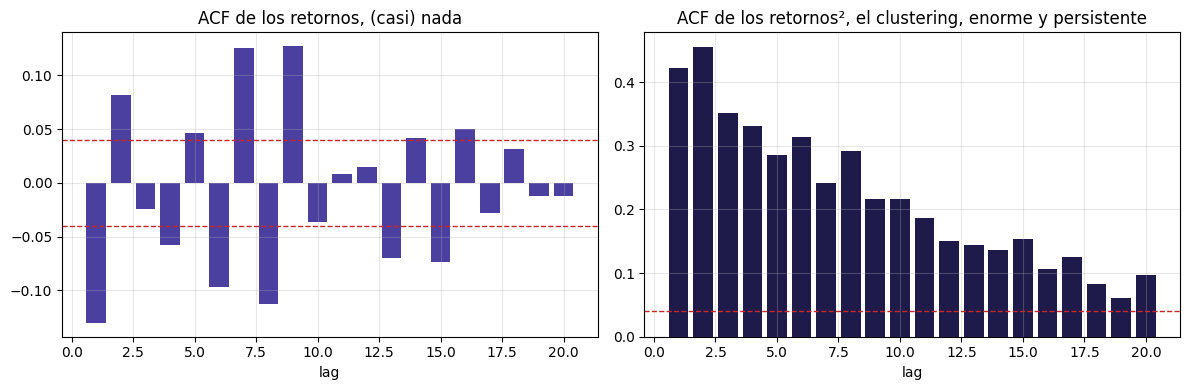

In [6]:
# ── Datos y diagnóstico: ADF + las dos ACF ────────────────────────────────────
try:
    spy = yf.download('SPY', period='10y', progress=False)['Close'].dropna().squeeze()
    fuente = 'datos en vivo'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(2)
    n = 2500; s2, eps = np.zeros(n), np.zeros(n); s2[0] = 1e-4
    for t in range(1, n):
        s2[t] = 2e-6 + 0.1*eps[t-1]**2 + 0.88*s2[t-1]
        eps[t] = np.sqrt(s2[t])*rng.standard_normal()
    spy = pd.Series(400*np.exp(np.cumsum(0.0003 + eps)), index=pd.date_range('2016-07-01', periods=n, freq='B'))

r = np.log(spy/spy.shift(1)).dropna()
print(f'[{fuente}] {len(r)} retornos diarios')

adf_p = adfuller(spy.values)[1]
adf_r = adfuller(r.values)[1]
print(f'ADF p-value, precios: {adf_p:.3f} (no estacionarios) | retornos: {adf_r:.4f} (estacionarios) ✓')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lags = range(1, 21)
axes[0].bar(lags, acf(r, nlags=20)[1:], color=VIOLET)
axes[0].axhline(2/np.sqrt(len(r)), color=RED, ls='--', lw=1); axes[0].axhline(-2/np.sqrt(len(r)), color=RED, ls='--', lw=1)
axes[0].set_title('ACF de los retornos, (casi) nada'); axes[0].set_xlabel('lag')
axes[1].bar(lags, acf(r**2, nlags=20)[1:], color=NAVY)
axes[1].axhline(2/np.sqrt(len(r)), color=RED, ls='--', lw=1)
axes[1].set_title('ACF de los retornos², el clustering, enorme y persistente'); axes[1].set_xlabel('lag')
plt.tight_layout(); plt.show()

In [7]:
# ── (a) El fracaso instructivo: ARIMA out-of-sample vs naive ──────────────────
train, test = r[:-250], r[-250:]

mejor_aic, mejor_orden = np.inf, None
for p_ in range(3):
    for q_ in range(3):
        if p_ == q_ == 0: continue
        try:
            aic = ARIMA(train, order=(p_, 0, q_)).fit().aic
            if aic < mejor_aic: mejor_aic, mejor_orden = aic, (p_, 0, q_)
        except Exception:
            pass
print(f'Mejor ARIMA por AIC: {mejor_orden}')

modelo = ARIMA(train, order=mejor_orden).fit()
pred = modelo.forecast(steps=250).values          # pronóstico multi-paso

rmse_arima = np.sqrt(np.mean((test.values - pred)**2))
rmse_naive = np.sqrt(np.mean((test.values - train.mean())**2))
print(f'RMSE out-of-sample, ARIMA: {rmse_arima*100:.4f}%  |  naive (la media): {rmse_naive*100:.4f}%')
print(f'Mejora del ARIMA sobre el naive: {(1 - rmse_arima/rmse_naive)*100:+.2f}%')
print()
print('El veredicto: estadísticamente NADA. El primer momento de los retornos diarios no se deja predecir con estructura lineal,')

Mejor ARIMA por AIC: (2, 0, 0)
RMSE out-of-sample, ARIMA: 0.8095%  |  naive (la media): 0.8096%
Mejora del ARIMA sobre el naive: +0.02%

El veredicto: estadísticamente NADA. El primer momento de los retornos diarios no se deja predecir con estructura lineal,


GARCH(1,1):  ω = 2.43e-06 | α = 0.120 | β = 0.857 | α+β = 0.977
Vol incondicional: 16.5% anual | half-life de un shock: 30 días


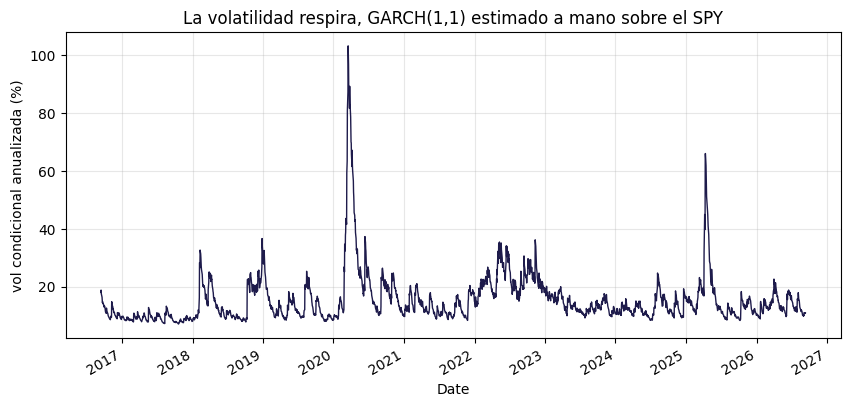

In [8]:
# ── (b) GARCH(1,1) por máxima verosimilitud, a mano ──────────────────────────
eps = (r - r.mean()).values

def neg_loglik(params, eps):
    omega, alpha, beta = params
    n = len(eps)
    s2 = np.empty(n); s2[0] = eps.var()
    for t in range(1, n):
        s2[t] = omega + alpha*eps[t-1]**2 + beta*s2[t-1]
    return 0.5*np.sum(np.log(2*np.pi*s2) + eps**2/s2)

res = minimize(neg_loglik, x0=[1e-6, 0.1, 0.85], args=(eps,),
               bounds=[(1e-9, 1e-3), (1e-4, 0.5), (0.5, 0.999)], method='L-BFGS-B')
omega, alpha_g, beta_g = res.x
print(f'GARCH(1,1):  ω = {omega:.2e} | α = {alpha_g:.3f} | β = {beta_g:.3f} | α+β = {alpha_g+beta_g:.3f}')
print(f'Vol incondicional: {np.sqrt(omega/(1-alpha_g-beta_g)*252)*100:.1f}% anual | half-life de un shock: {np.log(0.5)/np.log(alpha_g+beta_g):.0f} días')

# La σ_t condicional
n = len(eps); s2 = np.empty(n); s2[0] = eps.var()
for t in range(1, n):
    s2[t] = omega + alpha_g*eps[t-1]**2 + beta_g*s2[t-1]
sigma_t = pd.Series(np.sqrt(s2), index=r.index)

(sigma_t*np.sqrt(252)*100).plot(color=NAVY, lw=1)
plt.ylabel('vol condicional anualizada (%)')
plt.title('La volatilidad respira, GARCH(1,1) estimado a mano sobre el SPY')
plt.show()

Excedencias del VaR 99% en 2513 días (esperadas: ~25):
   VaR estático    : 47  |  agrupadas (≤5 días de otra): 48%
   VaR condicional : 51  |  agrupadas: 14%

Dos lecciones, no una:
 1. CANTIDAD: ambos exceden lo esperado → las innovaciones no son normales (colas t,
    la kurtosis de la clase 1). La cura: GARCH con innovaciones t-Student.
 2. AGRUPAMIENTO: las del estático se amontonan en las crisis (el banco muere UNA
    semana); las del condicional se reparten, el GARCH absorbió el clustering.
    Para el regulador, la independencia importa tanto como la cantidad (test de Christoffersen).


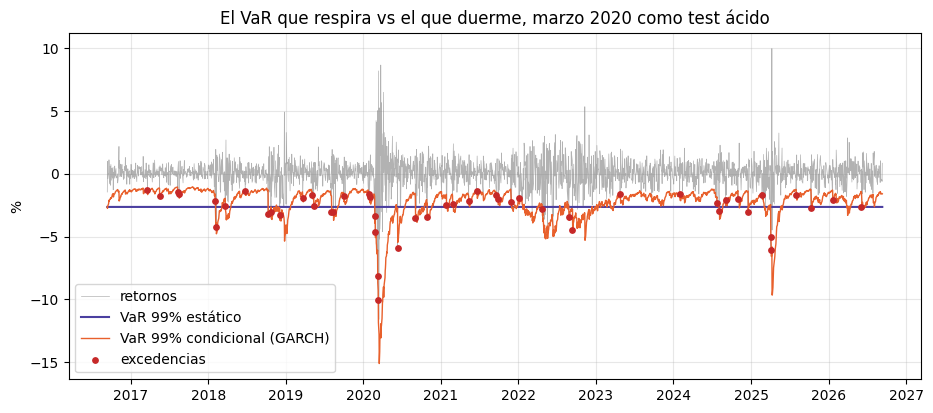

In [9]:
# ── VaR condicional vs estático: el backtest de excedencias ──────────────────
z99 = 2.326
var_estatico    = -z99 * r.std()                     # un solo número para 10 años
var_condicional = -z99 * sigma_t                     # respira con el mercado

exc_est  = (r < var_estatico)
exc_cond = (r < var_condicional)
esperadas = int(0.01 * len(r))

def agrupamiento(exc):
    """Fracción de excedencias que ocurren a ≤5 días de otra, mide el clustering."""
    fechas = np.where(exc.values)[0]
    if len(fechas) < 2: return 0.0
    return np.mean(np.diff(fechas) <= 5)

print(f'Excedencias del VaR 99% en {len(r)} días (esperadas: ~{esperadas}):')
print(f'   VaR estático    : {exc_est.sum()}  |  agrupadas (≤5 días de otra): {agrupamiento(exc_est):.0%}')
print(f'   VaR condicional : {exc_cond.sum()}  |  agrupadas: {agrupamiento(exc_cond):.0%}')
print()
print('Dos lecciones, no una:')
print(' 1. CANTIDAD: ambos exceden lo esperado → las innovaciones no son normales (colas t,')
print('    la kurtosis de la clase 1). La cura: GARCH con innovaciones t-Student.')
print(' 2. AGRUPAMIENTO: las del estático se amontonan en las crisis (el banco muere UNA')
print('    semana); las del condicional se reparten, el GARCH absorbió el clustering.')
print('    Para el regulador, la independencia importa tanto como la cantidad (test de Christoffersen).')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(r.index, r*100, lw=0.5, color='gray', alpha=0.6, label='retornos')
ax.plot(r.index, np.full(len(r), var_estatico*100), color=VIOLET, lw=1.5, label='VaR 99% estático')
ax.plot(r.index, var_condicional*100, color=ORANGE, lw=1, label='VaR 99% condicional (GARCH)')
mask = r < var_condicional
ax.scatter(r.index[mask], r[mask]*100, color=RED, s=15, zorder=3, label='excedencias')
ax.legend(); ax.set_ylabel('%'); ax.set_title('El VaR que respira vs el que duerme, marzo 2020 como test ácido')
plt.show()

---
# Ejercicio 3 , Lasso vs Ridge: la selección automática, en vivo

## La idea

El escenario del zoológico (§3 de la teórica) en miniatura: explicamos los retornos de una acción
con un panel de **8 factores reales** (ETFs: mercado, tamaño, value, growth, bonos, oro, crédito,
emergentes) al que le inyectamos **5 factores de ruido puro**, señales falsas que "publicó un
paper". El test: ¿la regularización descubre cuáles son falsos?

- **Ridge** (L2): encoge todo, no anula nada.
- **Lasso** (L1): debería poner los 5 factores de ruido **exactamente en cero**.

Y todo se juzga en el 20% final de la muestra (out-of-sample), nunca en el ajuste.

> *(Predicción: preguntas 5-6, ya las escribiste arriba de todo, antes de empezar.)*

In [10]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# ── Panel de factores: 8 reales (ETFs) + 5 de ruido inyectado ─────────────────
FACTOR_ETFS = ['SPY', 'IWM', 'IVE', 'IVW', 'TLT', 'GLD', 'HYG', 'EEM']
OBJETIVO = 'JPM'

try:
    px3 = yf.download(FACTOR_ETFS + [OBJETIVO], period='5y', progress=False)['Close'].dropna()
    fuente = 'datos en vivo'
except Exception as e:
    fuente = f'⚠ respaldo sintético ({e})'
    rng = np.random.default_rng(3)
    idx = pd.date_range('2021-07-01', periods=1250, freq='B')
    base = rng.normal(0, 0.01, (1250, len(FACTOR_ETFS)))
    px3 = pd.DataFrame(100*np.exp(np.cumsum(base, axis=0)), index=idx, columns=FACTOR_ETFS)
    px3[OBJETIVO] = 100*np.exp(np.cumsum(0.7*base[:, 0] + rng.normal(0, 0.008, 1250)))

r3 = np.log(px3/px3.shift(1)).dropna()
X = r3[FACTOR_ETFS].copy()
rng = np.random.default_rng(42)
for i in range(1, 6):                                   # los factores fantasma
    X[f'RUIDO_{i}'] = rng.normal(0, X['SPY'].std(), len(X))
y = r3[OBJETIVO].values

# División temporal (NO barajar: es una serie de tiempo)
corte = int(len(X)*0.8)
Xtr, Xte, ytr, yte = X[:corte], X[corte:], y[:corte], y[corte:]
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
print(f'[{fuente}] {len(X)} días | {X.shape[1]} factores (8 reales + 5 fantasma) | objetivo: {OBJETIVO}')

[datos en vivo] 1254 días | 13 factores (8 reales + 5 fantasma) | objetivo: JPM


In [11]:
# ── OLS vs Ridge vs Lasso, coeficientes y R² out-of-sample ───────────────────
modelos = {
    'OLS':   LinearRegression().fit(Xtr_s, ytr),
    'Ridge': RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(Xtr_s, ytr),
    'Lasso': LassoCV(n_alphas=50, max_iter=5000).fit(Xtr_s, ytr),
}

print(f'{"factor":<10}' + ''.join(f'{m:>10}' for m in modelos))
for j, col in enumerate(X.columns):
    fila = f'{col:<10}'
    for m in modelos.values():
        fila += f'{m.coef_[j]*1e4:>10.2f}'
    print(fila + ('   ← fantasma' if 'RUIDO' in col else ''))

print(f'\n{"R² out-of-sample:":<20}' + ''.join(f'{m.score(Xte_s, yte):>10.3f}' for m in modelos.values()))
anulados = int((np.abs(modelos['Lasso'].coef_[8:]) < 1e-10).sum())
print(f'\nFactores fantasma anulados por Lasso: {anulados}/5')
print('Ridge los encogió; Lasso los ejecutó. Esa es la diferencia entre L2 y L1.')

factor           OLS     Ridge     Lasso
SPY           -65.49    -34.41      0.00
IWM             9.20      9.61      4.71
IVE           137.41    124.35    105.89
IVW            32.58     12.25      0.00
TLT           -24.28    -24.37    -20.15
GLD            -9.45     -9.53     -4.39
HYG             0.19      0.51      0.00
EEM             7.10      7.06      0.56
RUIDO_1         4.62      4.59      0.27   ← fantasma
RUIDO_2        -3.76     -3.71     -0.00   ← fantasma
RUIDO_3         1.77      1.80      0.00   ← fantasma
RUIDO_4         2.89      2.83      0.00   ← fantasma
RUIDO_5        -0.30     -0.36     -0.00   ← fantasma

R² out-of-sample:        0.251     0.253     0.284

Factores fantasma anulados por Lasso: 4/5
Ridge los encogió; Lasso los ejecutó. Esa es la diferencia entre L2 y L1.


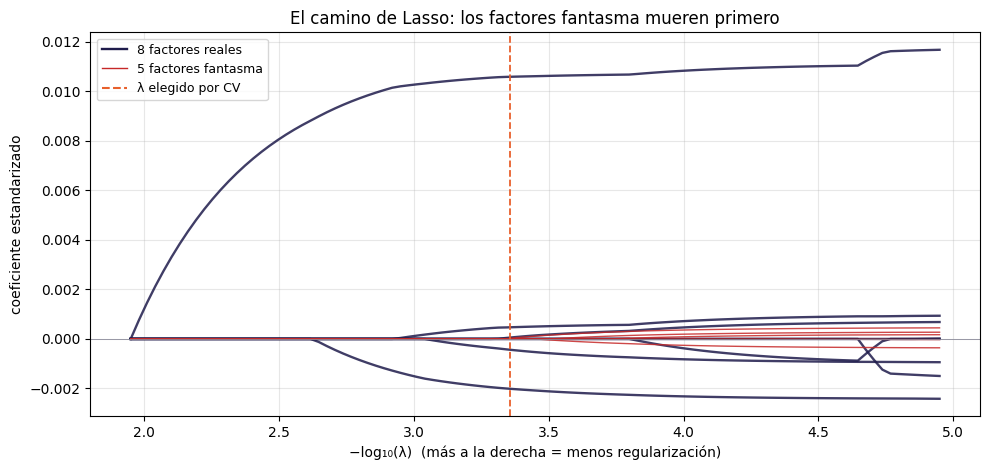

In [12]:
# ── La figura: el camino de Lasso, quién muere primero ──────────────────────
from sklearn.linear_model import lasso_path
alphas_path, coefs_path, _ = lasso_path(Xtr_s, ytr, n_alphas=100)

fig, ax = plt.subplots(figsize=(10, 4.8))
for j, col in enumerate(X.columns):
    es_ruido = 'RUIDO' in col
    ax.plot(-np.log10(alphas_path), coefs_path[j],
            color=RED if es_ruido else NAVY, lw=1.0 if es_ruido else 1.7, alpha=0.85)
ax.axvline(-np.log10(modelos['Lasso'].alpha_), color=ORANGE, ls='--', lw=1.3)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color=NAVY, lw=1.7, label='8 factores reales'),
    Line2D([0], [0], color=RED, lw=1.0, label='5 factores fantasma'),
    Line2D([0], [0], color=ORANGE, ls='--', label='λ elegido por CV'),
], fontsize=9)
ax.axhline(0, color='#8A8A9A', lw=0.6)
ax.set_xlabel('−log₁₀(λ)  (más a la derecha = menos regularización)')
ax.set_ylabel('coeficiente estandarizado')
ax.set_title('El camino de Lasso: los factores fantasma mueren primero')
plt.tight_layout(); plt.show()


---
# Ejercicio 4: El factor que se muere al publicarse

## McLean & Pontiff (2016): "Does Academic Research Destroy Stock Return Predictability?"

La Clase 6 va a citar este resultado de pasada ("los factores publicados pierden ~50% del
premio post-publicación"). Acá lo vamos a **reproducir con datos reales**, sobre uno de los
factores más famosos de las finanzas: **HML** (value menos growth), el mismo que usamos en el
Ejercicio 1, pero ahora con la serie académica completa (Ken French, desde 1926), no con
3 años de ETFs.

**La idea del experimento**: Fama y French publicaron HML como factor de riesgo en 1992-1993.
Antes de esa fecha, nadie fuera de un puñado de académicos sabía que "comprar barato (value) y
vender caro (growth)" tenía una prima histórica. Después, todo el mundo lo sabía, y si los
mercados aprenden, el arbitraje debería empezar a comérselo. Partimos la serie en dos en
**enero de 1993** y comparamos.

**Predicción antes de correr**: si McLean-Pontiff tienen razón, el Sharpe POST-1993 debería ser
claramente menor al PRE-1993. Y como bonus siniestro: HML tuvo una "década perdida" muy citada
(2010-2020) que vamos a aislar aparte.

> *(Predicción: pregunta 7, ya la escribiste arriba de todo, antes de empezar.)*

In [13]:
# ── Datos: Fama-French 3 factores, mensual, desde 1926 (Ken French Data Library) ──
import requests, zipfile, io

def bajar_ff_factors():
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
    resp = requests.get(url, timeout=20)
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    raw = z.read(z.namelist()[0]).decode('utf-8', errors='ignore')
    filas = []
    for line in raw.splitlines():
        line = line.strip()
        if not line or ',' not in line:
            continue
        partes = line.split(',')
        if len(partes) != 5 or not (partes[0].strip().isdigit() and len(partes[0].strip()) == 6):
            continue
        filas.append(partes)
    df = pd.DataFrame(filas, columns=['fecha', 'MktRF', 'SMB', 'HML', 'RF']).astype(
        {'fecha': str, 'MktRF': float, 'SMB': float, 'HML': float, 'RF': float})
    df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m')
    return df.set_index('fecha') / 100.0

try:
    ff = bajar_ff_factors()
    fuente_ff = 'Ken French Data Library (en vivo)'
except Exception as e:
    fuente_ff = f'⚠ respaldo fechado 9-ago-2026 ({e})'
    rng_ff = np.random.default_rng(9)
    idx_ff = pd.date_range('1926-07-01', periods=1200, freq='MS')
    hml_fb = np.concatenate([rng_ff.normal(0.0045, 0.037, 799), rng_ff.normal(0.0019, 0.033, 401)])
    ff = pd.DataFrame({'MktRF': rng_ff.normal(0.006, 0.05, 1200), 'SMB': rng_ff.normal(0, 0.03, 1200),
                       'HML': hml_fb, 'RF': 0.002}, index=idx_ff)

print(f'[{fuente_ff}] {len(ff)} meses, {ff.index[0].strftime("%Y-%m")} → {ff.index[-1].strftime("%Y-%m")}')

[Ken French Data Library (en vivo)] 1201 meses, 1926-07 → 2026-07


In [14]:
# ── HML antes y después de que Fama-French lo publicaran (1992-1993) ──────────
PUBLICACION = '1993-01-01'
pre, post = ff.loc[:PUBLICACION, 'HML'], ff.loc[PUBLICACION:, 'HML']

def stats_anualizadas(x):
    ret = x.mean() * 12
    vol = x.std() * np.sqrt(12)
    return ret, vol, ret / vol

print(f'{"":<28}{"n meses":>9}{"ret. anual":>12}{"vol. anual":>12}{"Sharpe":>9}')
for nombre, serie in [('PRE (hasta dic-1992)', pre), ('POST (desde ene-1993)', post)]:
    ret, vol, sharpe = stats_anualizadas(serie)
    print(f'{nombre:<28}{len(serie):>9}{ret:>+12.2%}{vol:>12.2%}{sharpe:>9.2f}')

decada = ff.loc['2010-01-01':'2020-12-31', 'HML']
ret_d, vol_d, sharpe_d = stats_anualizadas(decada)
print(f"\n{'2010-2020 (decada perdida)':<28}{len(decada):>9}{ret_d:>+12.2%}{vol_d:>12.2%}{sharpe_d:>9.2f}")

_, _, sh_pre = stats_anualizadas(pre)
_, _, sh_post = stats_anualizadas(post)
caida = 1 - sh_post / sh_pre
print(f'\nEl Sharpe cayó {caida:.0%} después de la publicación, McLean-Pontiff, con nuestros propios datos.')

                              n meses  ret. anual  vol. anual   Sharpe
PRE (hasta dic-1992)              799      +5.34%      12.75%     0.42
POST (desde ene-1993)             403      +2.28%      11.39%     0.20

2010-2020 (decada perdida)        132      -5.31%       9.16%    -0.58

El Sharpe cayó 52% después de la publicación, McLean-Pontiff, con nuestros propios datos.


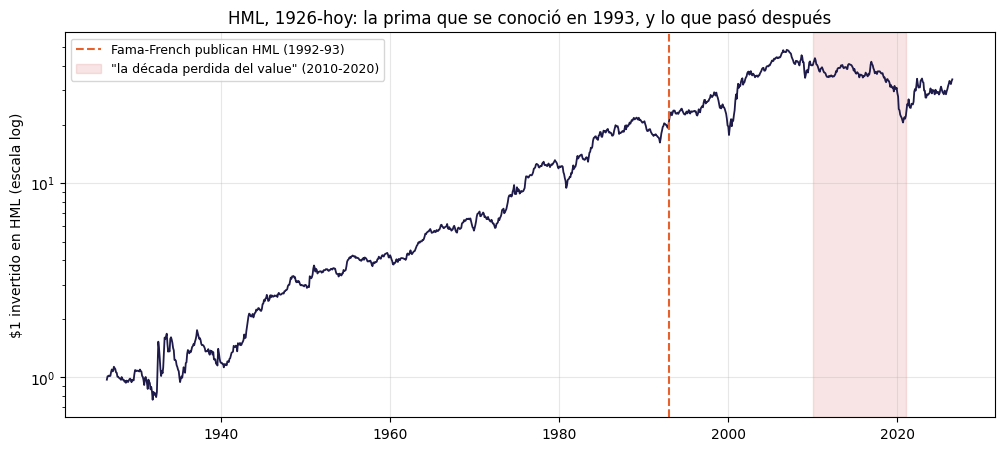

In [15]:
# ── La figura: el acumulado de HML, con la publicación y la década perdida marcadas ──
acumulado = (1 + ff['HML']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(acumulado.index, acumulado.values, color=NAVY, lw=1.3)
ax.axvline(pd.Timestamp(PUBLICACION), color=ORANGE, lw=1.5, ls='--',
           label='Fama-French publican HML (1992-93)')
ax.axvspan(pd.Timestamp('2010-01-01'), pd.Timestamp('2020-12-31'), color=RED, alpha=0.12,
           label='"la década perdida del value" (2010-2020)')
ax.set_yscale('log')
ax.set_ylabel('$1 invertido en HML (escala log)')
ax.set_title('HML, 1926-hoy: la prima que se conoció en 1993, y lo que pasó después')
ax.legend(fontsize=9)
plt.show()